# EDA 05 — Análisis bivariado del empleo adecuado

**Objetivo:** comparar descriptivamente el porcentaje ponderado de empleo adecuado por sexo, área, edad, nivel educativo y provincia.

El dominio contiene 39 551 registros. La tasa se calcula como suma ponderada de empleo adecuado dividida para la suma de pesos del grupo. Las diferencias están en puntos porcentuales. Todavía no se calculan errores estándar ni intervalos de confianza.

Esta descripción poblacional usa el dominio anual completo. La prueba predictiva permanece cerrada y las conclusiones de esta etapa no modificarán variables, semilla, pliegues, hiperparámetros ni umbral.

In [2]:
# ETAPA 5 / ARCHIVO: cuaderno 05 / BLOQUE 1: localizar resultados verificados.
from pathlib import Path  # Representa archivos y carpetas.
import json  # Lee los informes estructurados.
import pandas as pd  # Trabaja con tablas.
from IPython.display import SVG, display  # Presenta tablas y gráficos vectoriales.
RAIZ = Path.cwd() if (Path.cwd() / 'reports/eda05_bivariado').exists() else Path.cwd().parent  # Admite iniciar en proyecto o notebooks.
REPORTES = RAIZ / 'reports/eda05_bivariado'  # Localiza tablas.
FIGURAS = RAIZ / 'reports/figures/eda05_bivariado'  # Localiza figuras.
resumen = json.loads((REPORTES / '00_resumen_eda05.json').read_text(encoding='utf-8'))  # Lee resultados centrales.
verificacion = json.loads((REPORTES / '06_verificacion_eda05.json').read_text(encoding='utf-8'))  # Lee controles.
assert verificacion['estado'] == 'verificado'  # Exige una ejecución validada.
assert verificacion['prueba_predictiva_evaluada'] is False  # Confirma la separación predictiva.
display(pd.Series(resumen, name='valor').to_frame())  # Presenta el alcance general.

,valor
estado,completado
filas_dominio,39551
tasa_total_ponderada,68.853455
tasa_hombres,72.098371
tasa_mujeres,66.188635
brecha_mujeres_menos_hombres_pp,-5.909736
tasa_urbana,70.410856
tasa_rural,59.43693
brecha_rural_menos_urbana_pp,-10.973926
tasa_superior_no_universitaria,63.907587


## 1. Tasa total y comparación por sexo

La tasa total ponderada es 68,9 %. En hombres es 72,1 % y en mujeres, 66,2 %. La diferencia mujeres menos hombres es −5,9 puntos porcentuales. Esta brecha es descriptiva; su intervalo de confianza está pendiente.

,etiqueta,n,porcentaje_no_ponderado,porcentaje_ponderado,diferencia_referencia_pp,upm,estratos
1,Hombre,18198,71.86504,72.098371,0.000000,5081,150
2,Mujer,21353,67.98108,66.188635,-5.909736,5575,150


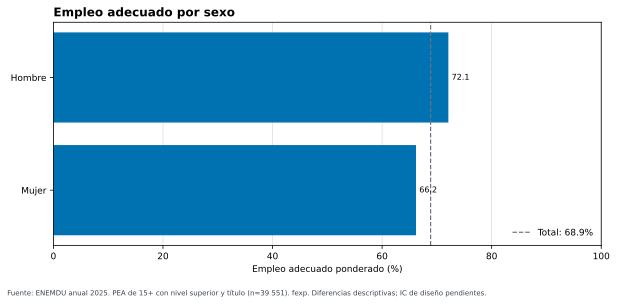

In [3]:
# BLOQUE 2: revisar tasas por sexo y su referencia.
tasas = pd.read_csv(REPORTES / '01_tasas_empleo_adecuado_grupos.csv', dtype={'codigo': 'string', 'codigo_referencia': 'string'})  # Lee la tabla principal conservando códigos.
sexo = tasas.loc[tasas['variable'] == 'p02']  # Selecciona sexo.
display(sexo[['etiqueta', 'n', 'porcentaje_no_ponderado', 'porcentaje_ponderado', 'diferencia_referencia_pp', 'upm', 'estratos']])  # Muestra tasa y diferencia.
display(SVG(filename=str(FIGURAS / '01_empleo_adecuado_sexo.svg')))  # Presenta el gráfico editable.

## 2. Área de residencia

La tasa urbana es 70,4 % y la rural, 59,4 %. La diferencia rural menos urbana es −11,0 puntos porcentuales. La composición territorial puede estar relacionada con estructura productiva, edad, provincia y otras características; la comparación no demuestra causalidad.

,etiqueta,n,porcentaje_ponderado,diferencia_referencia_pp,n_efectivo_pesos_kish
3,Urbana,35099,70.410856,0.000000,7741.017111
4,Rural,4452,59.436930,-10.973926,1109.049712


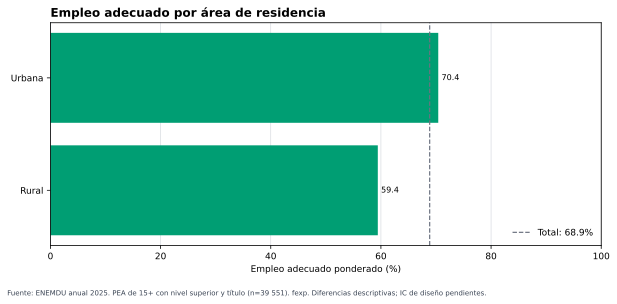

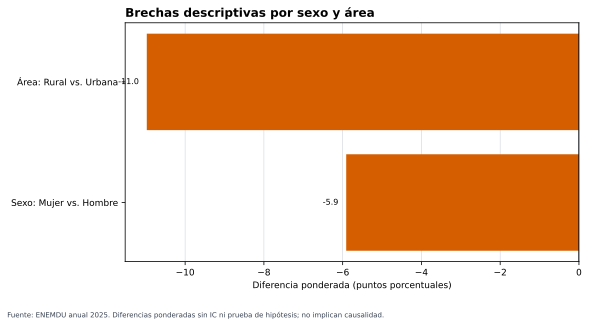

In [4]:
# BLOQUE 3: revisar tasas y brecha por área.
area = tasas.loc[tasas['variable'] == 'area']  # Selecciona área.
display(area[['etiqueta', 'n', 'porcentaje_ponderado', 'diferencia_referencia_pp', 'n_efectivo_pesos_kish']])  # Muestra resultados y tamaño efectivo por pesos.
display(SVG(filename=str(FIGURAS / '02_empleo_adecuado_area.svg')))  # Presenta tasas.
display(SVG(filename=str(FIGURAS / '06_brechas_sexo_area.svg')))  # Presenta las dos brechas principales.

## 3. Edad

El porcentaje aumenta durante la entrada y consolidación laboral, permanece cerca de 77–79 % entre 35 y 59 años y disminuye después. Los extremos tienen tamaños pequeños: 11 observaciones entre 15–19 y 5 entre 85–89. Sus valores no son conclusiones estables.

La forma no lineal es una señal para comparar especificaciones de edad dentro de entrenamiento; no autoriza a ajustar el modelo usando la prueba.

,etiqueta,n,porcentaje_ponderado,diferencia_referencia_pp,upm,estratos
5,15–19,11,2.998300,-65.967854,8,8
6,20–24,2411,40.628429,-28.337725,1531,146
7,25–29,6783,57.551548,-11.414606,3199,146
8,30–34,6577,68.966154,0.000000,3003,149
9,35–39,5290,77.040478,8.074324,2520,146
10,40–44,4769,76.635554,7.669400,2254,140
11,45–49,3935,78.745222,9.779067,1971,137
12,50–54,3600,77.453605,8.487450,1842,133
13,55–59,2891,78.401608,9.435454,1522,137
14,60–64,1875,68.786900,-0.179255,1062,118


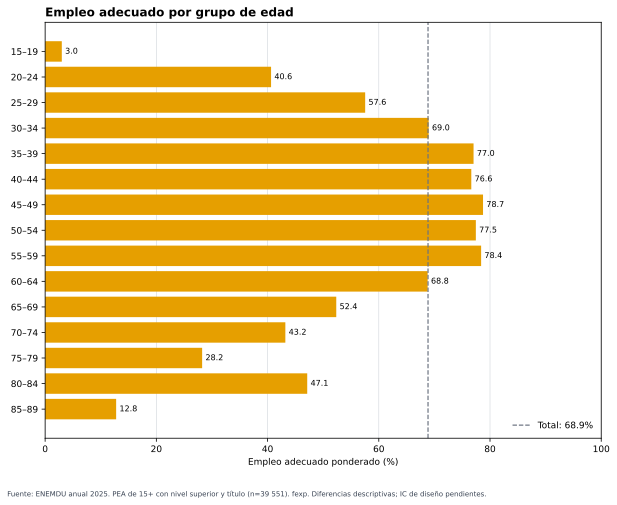

In [5]:
# BLOQUE 4: revisar la curva descriptiva por edad.
edad = tasas.loc[tasas['variable'] == 'grupo_edad']  # Selecciona grupos de edad.
display(edad[['etiqueta', 'n', 'porcentaje_ponderado', 'diferencia_referencia_pp', 'upm', 'estratos']])  # Hace visibles tamaños y tasas.
display(SVG(filename=str(FIGURAS / '03_empleo_adecuado_edad.svg')))  # Presenta la distribución bivariada.

## 4. Nivel educativo reportado

Las tasas son 63,9 % en superior no universitaria, 66,3 % en superior universitaria y 85,6 % en posgrado. Frente al nivel universitario, las diferencias son −2,4 y +19,3 puntos porcentuales. `p10a` es nivel reportado, no necesariamente el título más alto.

,etiqueta,n,porcentaje_ponderado,etiqueta_referencia,diferencia_referencia_pp
20,Post-grado,7262,85.584374,Superior Universitario,19.305507
21,Superior no universitario,6425,63.907587,Superior Universitario,-2.371280
22,Superior Universitario,25864,66.278867,Superior Universitario,0.000000


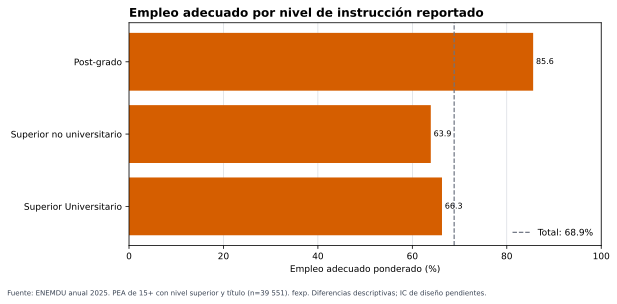

In [6]:
# BLOQUE 5: revisar educación y referencias.
educacion = tasas.loc[tasas['variable'] == 'p10a']  # Selecciona nivel de instrucción.
display(educacion[['etiqueta', 'n', 'porcentaje_ponderado', 'etiqueta_referencia', 'diferencia_referencia_pp']])  # Presenta contrastes descriptivos.
display(SVG(filename=str(FIGURAS / '04_empleo_adecuado_educacion.svg')))  # Presenta tasas educativas.

## 5. Provincia

El rango va de 48,1 % en Chimborazo a 89,7 % en Morona Santiago. Las posiciones no son una clasificación definitiva: las provincias tienen tamaños y composiciones diferentes. La incertidumbre y las comparaciones múltiples se resolverán antes de publicar conclusiones territoriales.

,etiqueta,n,porcentaje_ponderado,diferencia_total_pp,upm,estratos
43,Chimborazo,778,48.077015,-20.776440,110,6
42,Cotopaxi,880,55.376186,-13.477269,124,6
26,Los Ríos,389,60.133473,-8.719982,88,6
25,Loja,1197,62.367181,-6.486274,203,6
32,Tungurahua,5217,62.447714,-6.405740,623,9
24,Imbabura,1477,62.634335,-6.219119,266,6
45,Esmeraldas,1510,64.426267,-4.427188,297,6
30,Pastaza,826,64.729548,-4.123907,128,6
41,Carchi,683,64.920066,-3.933389,135,6
29,Napo,560,65.368244,-3.485211,98,4


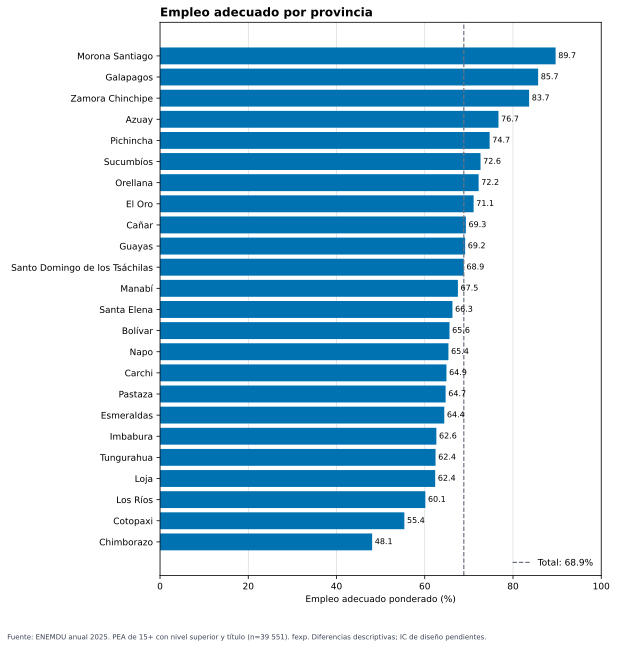

In [7]:
# BLOQUE 6: revisar territorio y diagnósticos de precisión futura.
provincia = tasas.loc[tasas['variable'] == 'prov'].sort_values('porcentaje_ponderado')  # Ordena provincias por tasa.
display(provincia[['etiqueta', 'n', 'porcentaje_ponderado', 'diferencia_total_pp', 'upm', 'estratos']])  # Muestra tasa y soporte muestral.
display(SVG(filename=str(FIGURAS / '05_empleo_adecuado_provincia.svg')))  # Presenta la comparación territorial.

## 6. Preparación de la inferencia

El archivo compacto de diseño contiene las 334 786 filas, 150 estratos y 7 780 UPM. Para un dominio no se deben conservar solamente las filas elegibles: las UPM sin casos aportan cero, pero forman parte de la estimación de variación.

La próxima etapa aplicará linealización de Taylor. Las diferencias usarán su covarianza conjunta; no se tratarán los grupos como muestras independientes. Véase `docs/09_plan_inferencia_diseno.md`.

In [8]:
# BLOQUE 7: verificar el archivo preparado para diseño complejo.
control = pd.read_csv(REPORTES / '04_control_archivo_inferencia.csv')  # Lee el control sin cargar las 334 786 filas.
diagnostico = pd.read_csv(REPORTES / '03_diagnostico_diseno_grupos.csv')  # Lee alertas por categoría.
display(control)  # Presenta filas, estratos, UPM y grados de libertad.
display(diagnostico.loc[diagnostico['advertencia'] != 'sin alerta descriptiva'].head(20))  # Hace visibles grupos que requieren cautela.
assert control.loc[0, 'filas'] == 334786  # Exige la muestra completa.
assert control.loc[0, 'filas_dominio'] == 39551  # Reconcilia el dominio.

,filas,estratos,upm,grados_libertad_diseno,filas_dominio,numerador_adecuado,pesos_positivos,sha256
0,334786,150,7780,7630,39551,27594,True,b0c91f874d911ca67518b787bae0e3973631923a0a536f...


,variable,codigo,etiqueta,n,upm,estratos,n_efectivo_pesos_kish,estratos_una_upm_en_subgrupo,advertencia
1,p02,1,Hombre,18198,5081,150,4155.064712,1,algunos estratos tienen una UPM con casos; con...
5,grupo_edad,15–19,15–19,11,8,8,8.026557,8,n menor que 100; interpretar con cautela
6,grupo_edad,20–24,20–24,2411,1531,146,533.187225,9,algunos estratos tienen una UPM con casos; con...
7,grupo_edad,25–29,25–29,6783,3199,146,1590.318535,2,algunos estratos tienen una UPM con casos; con...
8,grupo_edad,30–34,30–34,6577,3003,149,1334.336755,7,algunos estratos tienen una UPM con casos; con...
9,grupo_edad,35–39,35–39,5290,2520,146,1169.756704,12,algunos estratos tienen una UPM con casos; con...
10,grupo_edad,40–44,40–44,4769,2254,140,1390.405595,9,algunos estratos tienen una UPM con casos; con...
11,grupo_edad,45–49,45–49,3935,1971,137,900.332983,20,algunos estratos tienen una UPM con casos; con...
12,grupo_edad,50–54,50–54,3600,1842,133,752.702320,18,algunos estratos tienen una UPM con casos; con...
13,grupo_edad,55–59,55–59,2891,1522,137,668.386889,26,algunos estratos tienen una UPM con casos; con...


## 7. Reflexión

- Una diferencia descriptiva no es todavía “significativa”.
- La asociación bivariada puede cambiar al ajustar simultáneamente otras características.
- Ningún resultado demuestra efectos de sexo, residencia, edad o educación.
- Los grupos pequeños requieren intervalos y reglas de publicación.
- La regresión logística responderá la hipótesis ajustada; el modelo de árboles responderá la comparación predictiva.

**Ejercicio:** identifica el numerador y denominador de la tasa rural. Explica por qué para su intervalo deben conservarse también UPM sin personas rurales del dominio.